# Test Model Acidity

In [86]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from seapopym.configuration.acidity.acidity_configuration import AcidityConfiguration, AcidityForcingParameters, AcidityParameters
from seapopym.configuration.no_transport.parameter import  FunctionalGroups
from seapopym.configuration.parameters.parameter_forcing import ForcingUnit
from seapopym.configuration.parameters.parameter_functional_group import (
    FunctionalGroupUnitMigratoryParameters,
    FunctionalGroupUnitRelationParameters,
    FunctionalGroupUnit,
)
from seapopym.logging.custom_logger import set_verbose
from seapopym.model.acidity_model import AcidityModel
from seapopym.standard import coordinates
from seapopym.standard.units import StandardUnitsLabels

set_verbose()

## Loading data for 1D simulation

In [87]:
# Set time axis (one year, 365 days - no leap year)
time_axis = coordinates.new_time(pd.date_range("2001-01-01", "2001-12-31", freq="D")) 
n = int(time_axis.size)
t = np.linspace(0, 1, n)

# Create the mapping MM-DD -> day (except leap years)
days = pd.date_range('2001-01-01', '2001-12-31')  # 2001 not a leap year
mmdd_to_day = {d.strftime('%m-%d'): i+1 for i, d in enumerate(days)}

In [88]:
# load temperature
path_temp="/data/rd_exchange/sroyer/SEAPOPYM/daily_temp_papa_1998_2020.nc"
ds_temp = xr.open_dataset(path_temp,engine='netcdf4')
ds_temp

<xarray.Dataset> Size: 302kB
Dimensions:  (time: 8395)
Coordinates:
  * time     (time) datetime64[ns] 67kB 1998-01-01T12:00:00 ... 2020-12-31T12...
    day      (time) <U5 168kB ...
Data variables:
    T        (time) float64 67kB ...

In [89]:
# Extract temperature 
temp = ds_temp['T']


# assign day coordinate in ds_temp
# Extract MM-DD 
mmdd = pd.to_datetime(temp.time.values).strftime('%m-%d')
# transform MM-DD in indice of day in year (1->365)
day_noleap = pd.Series(mmdd).map(mmdd_to_day).values
# add coord day
temp = temp.assign_coords(day=("time", day_noleap))

#compute median
median_temp = temp.groupby('day').median('time')

#smooth median 
# Pad 15 days on each side cyclically
pad_width = 15
extended = xr.concat(
    [median_temp.isel(day=slice(-pad_width, None)),  # wrap end -> beginning
     median_temp,
     median_temp.isel(day=slice(0, pad_width))],     # wrap beginning -> end
    dim='day'
)

# Fix the 'day' coordinate (but for clarity)
extended['day'] = np.arange(-pad_width, 365 + pad_width)

# Apply the rolling mean
smoothed = extended.rolling(day=30, center=True).mean()

# Extract the center part (original days)
median_temp_smooth = smoothed.sel(day=slice(1, 365))


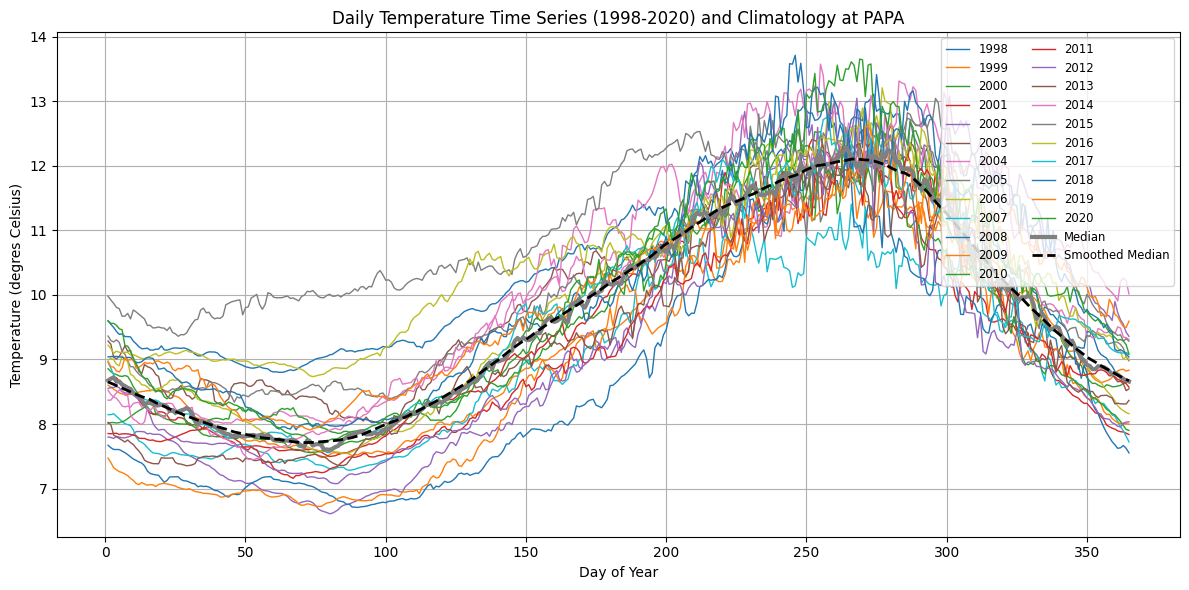

In [90]:
# Plot Temperature Forcing
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Group by year
years = np.unique(pd.DatetimeIndex(temp.time.values).year)

# Plot one line per year
for year in years:
    yearly_data = temp.sel(time=str(year))
    ax.plot(yearly_data['day'], yearly_data.values, linewidth=1, label=str(year))

# Plot median in thick grey
ax.plot(median_temp['day'], median_temp.values, color='grey', linewidth=3, label='Median')

# Plot smoothed median in thin black
ax.plot(median_temp_smooth['day'], median_temp_smooth.values, color='black', linewidth=2, linestyle='--', label='Smoothed Median')

# Axis labels and title
ax.set_title('Daily Temperature Time Series (1998-2020) and Climatology at PAPA')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Temperature (degres Celsius)')

# Add legend
ax.legend(loc='upper right', fontsize='small', ncol=2)

# Style and layout
ax.grid(True)
plt.tight_layout()
plt.show()


In [91]:
temperature = xr.DataArray(
    dims=["time", "latitude", "longitude", "layer"],
    coords={
        "time": coordinates.new_time(pd.date_range("2001-01-01", "2001-12-31", freq="D")),
        "latitude": coordinates.new_latitude([0]),
        "longitude": coordinates.new_longitude([0]),
        "layer": coordinates.new_layer([0]),
    },
    attrs={"units": StandardUnitsLabels.temperature},
    data=median_temp_smooth.values[:, np.newaxis, np.newaxis, np.newaxis],
)

In [123]:
# load primary production
path_pp="/data/rd_exchange/sroyer/SEAPOPYM/NPP/daily_CAFE_papa_1998_2020.nc"
ds_pp = xr.open_dataset(path_pp,engine='netcdf4')

In [124]:
# Extract net primary production
pp = ds_pp['npp']

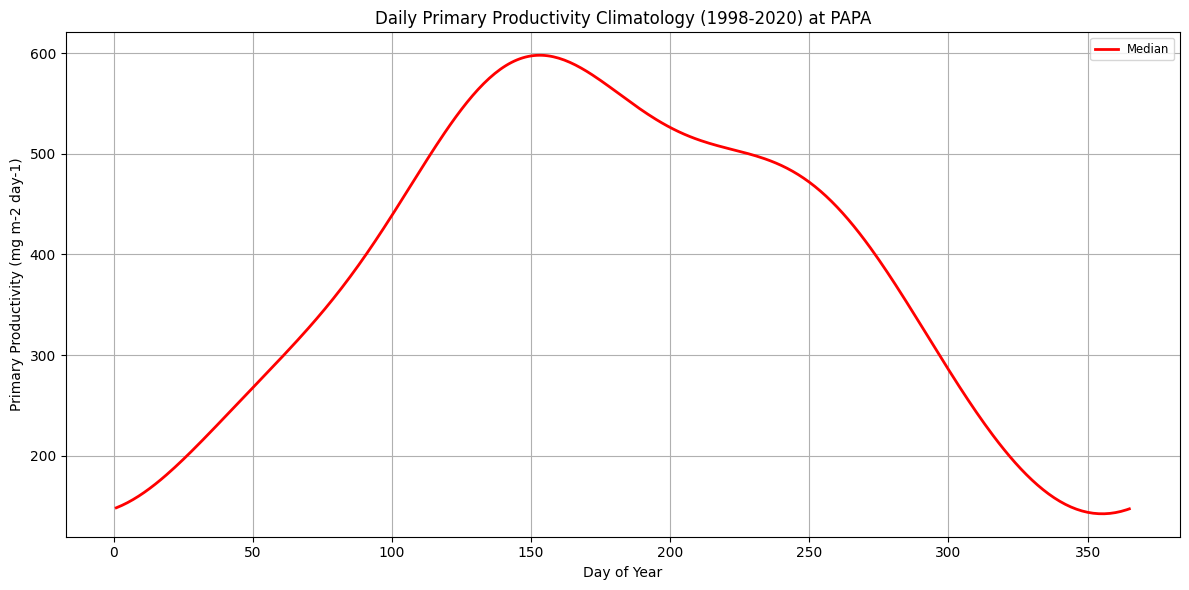

In [125]:
# Plot Primary Productivity Forcing
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot median 
ax.plot(pp['days'], pp.values, color='red', linewidth=2, label='Median')

# Axis labels and title
ax.set_title('Daily Primary Productivity Climatology (1998-2020) at PAPA')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Primary Productivity (mg m-2 day-1)')

# Add legend
ax.legend(loc='upper right', fontsize='small', ncol=2)

# Style and layout
ax.grid(True)
plt.tight_layout()
plt.show()


In [126]:
primary_production = xr.DataArray(
    dims=["time", "latitude", "longitude"],
    coords={
        "time": coordinates.new_time(pd.date_range("2001-01-01", "2001-12-31", freq="D")),
        "latitude": coordinates.new_latitude([0]),
        "longitude": coordinates.new_longitude([0]),
    },
    attrs={"units": "mg m-2 day-1"},
    data=pp.values[:, np.newaxis, np.newaxis],
)

In [96]:
# Load pH
path_pH="/data/rd_exchange/sroyer/SEAPOPYM/daily_acidity_papa_1998_2020.nc"
ds_pH = xr.open_dataset(path_pH,engine='netcdf4')

In [97]:
ds_pH['days']

<xarray.DataArray 'days' (days: 365)> Size: 3kB
array([  1,   2,   3, ..., 363, 364, 365])
Coordinates:
  * days     (days) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

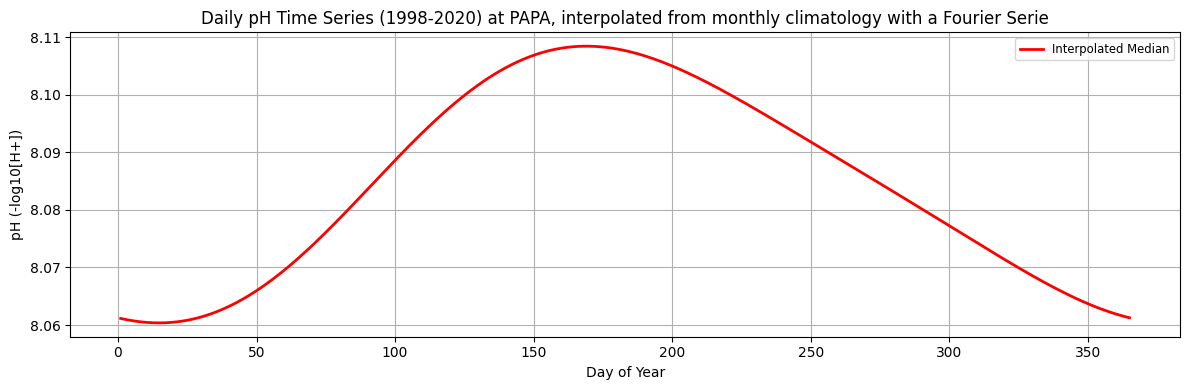

In [98]:
# Plot pH
data_pH=ds_pH['pH']

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 4))

# Plot  in thin black
ax.plot(ds_pH['days'].values, data_pH.values, color='red', linewidth=2, label='Interpolated Median')

# Axis labels and title
ax.set_title('Daily pH Time Series (1998-2020) at PAPA, interpolated from monthly climatology with a Fourier Serie')
ax.set_xlabel('Day of Year')
ax.set_ylabel('pH (-log10[H+])')

# Add legend
ax.legend(loc='upper right', fontsize='small', ncol=2)

# Style and layout
ax.grid(True)
plt.tight_layout()
plt.show()


In [99]:
acidity = xr.DataArray(
    dims=["time", "latitude", "longitude", "layer"],
    coords={
        "time": coordinates.new_time(pd.date_range("2001-01-01", "2001-12-31", freq="D")),
        "latitude": coordinates.new_latitude([0]),
        "longitude": coordinates.new_longitude([0]),
        "layer": coordinates.new_layer([0]),
    },
    attrs={"units": StandardUnitsLabels.acidity},
    data=data_pH.values[:, np.newaxis, np.newaxis, np.newaxis],
)


In [127]:
dataset = xr.Dataset({"temperature": temperature,"primary_production": primary_production,"acidity":acidity})

## Initialize the model

In [149]:
from seapopym.configuration.no_transport.parameter import KernelParameters

day_layer = 0
night_layer = 0
tr_max = 41.61
tr_rate = -0.085
lambda_T_max = 0.04#1/0.092
lambda_T_rate = 1/256.75
lambda_pH_max= 2.4
lambda_pH_rate= -0.58

f_groups = FunctionalGroups(
    functional_groups=[
        FunctionalGroupUnit(
            name=f"D{day_layer}N{night_layer}",
            migratory_type=FunctionalGroupUnitMigratoryParameters(day_layer=day_layer, night_layer=night_layer),
            functional_type=FunctionalGroupUnitRelationParameters(
                lambda_T_max=lambda_T_max,
                lambda_T_rate=lambda_T_rate,
                lambda_pH_max=lambda_pH_max,
                lambda_pH_rate=lambda_pH_rate,
                temperature_recruitment_rate=tr_rate,
                cohorts_timesteps=[1] * np.ceil(tr_max).astype(int),
                temperature_recruitment_max=tr_max,
            ),
            energy_transfert=0.001668,
        )
    ]
)

p_param = AcidityForcingParameters(
    acidity=ForcingUnit(forcing=dataset["acidity"], resolution=1),
    temperature=ForcingUnit(forcing=dataset["temperature"], resolution=1),
    primary_production=ForcingUnit(forcing=dataset["primary_production"], resolution=1),
)

parameters = AcidityParameters(
    functional_groups_parameters=f_groups,
    forcing_parameters=p_param,
    kernel_parameters=KernelParameters(compute_preproduction=True),
)
acidity_model = AcidityModel(configuration=AcidityConfiguration(parameters))
acidity_model.state

2025-04-23 10:54:57,123 :: Seapodym ::  WARNING ::
|	Parameter inv_lambda_rate : 0.0 has a null value. It means that the mortality is not affected by temperature. Do you really mean to use this value?

2025-04-23 10:54:57,230 :: Seapodym ::  WARNING ::
|	primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.



<xarray.Dataset> Size: 14kB
Dimensions:                       (functional_group: 1, time: 365, latitude: 1,
                                   longitude: 1, layer: 1, cohort: 42)
Coordinates:
  * functional_group              (functional_group) int64 8B 0
  * time                          (time) datetime64[ns] 3kB 2001-01-01 ... 20...
  * latitude                      (latitude) int64 8B 0
  * longitude                     (longitude) int64 8B 0
  * layer                         (layer) int64 8B 0
  * cohort                        (cohort) int64 336B 0 1 2 3 4 ... 38 39 40 41
Data variables: (12/22)
    name                          (functional_group) <U4 16B 'D0N0'
    energy_transfert              (functional_group) float64 8B 0.001668
    inv_lambda_max                (functional_group) float64 8B 1.0
    inv_lambda_rate               (functional_group) float64 8B 0.0
    lambda_T_max                  (functional_group) float64 8B 0.04
    lambda_T_rate                 (functional_group) float64 8B 0.003895
    ...                            ...
    resolution_latitude           float64 8B 1.0
    resolution_longitude          float64 8B 1.0
    timesteps_number              (functional_group, cohort) int64 336B 1 ... 1
    min_timestep                  (functional_group, cohort) int64 336B 1 ... 42
    max_timestep                  (functional_group, cohort) int64 336B 1 ... 42
    mean_timestep                 (functional_group, cohort) float64 336B 1.0...

## First Run the model to get initial conditions

In [150]:
acidity_model.run()
acidity_model.state.load()

<xarray.Dataset> Size: 172kB
Dimensions:                       (functional_group: 1, time: 365, latitude: 1,
                                   longitude: 1, layer: 1, cohort: 42)
Coordinates:
  * functional_group              (functional_group) int64 8B 0
  * time                          (time) datetime64[ns] 3kB 2001-01-01 ... 20...
  * latitude                      (latitude) int64 8B 0
  * longitude                     (longitude) int64 8B 0
  * layer                         (layer) int64 8B 0
  * cohort                        (cohort) int64 336B 0 1 2 3 4 ... 38 39 40 41
Data variables: (12/35)
    name                          (functional_group) <U4 16B 'D0N0'
    energy_transfert              (functional_group) float64 8B 0.001668
    inv_lambda_max                (functional_group) float64 8B 1.0
    inv_lambda_rate               (functional_group) float64 8B 0.0
    lambda_T_max                  (functional_group) float64 8B 0.04
    lambda_T_rate                 (functional_group) float64 8B 0.003895
    ...                            ...
    mask_temperature              (functional_group, time, latitude, longitude, cohort) bool 15kB ...
    cell_area                     (latitude, longitude) float64 8B 1.236e+10
    mortality_field               (functional_group, time, latitude, longitude) float64 3kB ...
    recruited                     (functional_group, time, latitude, longitude) float64 3kB ...
    preproduction                 (functional_group, time, latitude, longitude, cohort) float64 123kB ...
    biomass                       (functional_group, time, latitude, longitude) float64 3kB ...

## Plotting the results

### The biomass evolution over time

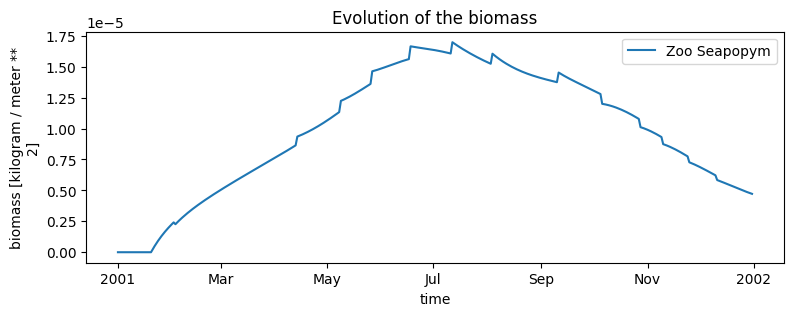

In [151]:
plt.figure(figsize=(9, 3))
acidity_model.plot_biomass(label="Zoo Seapopym")
plt.legend()
plt.title("Evolution of the biomass")
plt.show()

### And the production over time

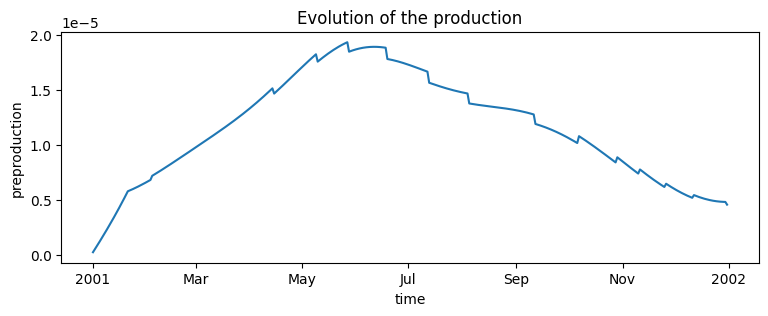

In [152]:
plt.figure(figsize=(9, 3))
acidity_model.state.preproduction[0].cf.mean(("X", "Y")).cf.sum("cohort").cf.plot.line(x="T")
plt.title("Evolution of the production")
plt.show()

## Run the model

In [153]:
init_production = acidity_model.state.preproduction.isel(time=-1).drop_vars('time')
init_biomass = acidity_model.state.biomass.isel(time=-1).drop_vars('time')

In [154]:
p_param2 = AcidityForcingParameters(
    acidity=ForcingUnit(forcing=dataset["acidity"], resolution=1),
    temperature=ForcingUnit(forcing=dataset["temperature"], resolution=1),
    primary_production=ForcingUnit(forcing=dataset["primary_production"], resolution=1),
    initial_condition_production=ForcingUnit(forcing=init_production,resolution=1),
    initial_condition_biomass=ForcingUnit(forcing=init_biomass,resolution=1)
)

parameters2 = AcidityParameters(
    functional_groups_parameters=f_groups,
    forcing_parameters=p_param2,
    kernel_parameters=KernelParameters(compute_preproduction=True),
)
acidity_model2 = AcidityModel(configuration=AcidityConfiguration(parameters2))
acidity_model2.state

2025-04-23 10:55:08,785 :: Seapodym ::  WARNING ::
|	primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.



<xarray.Dataset> Size: 14kB
Dimensions:                       (functional_group: 1, time: 365, latitude: 1,
                                   longitude: 1, layer: 1, cohort: 42)
Coordinates:
  * functional_group              (functional_group) int64 8B 0
  * time                          (time) datetime64[ns] 3kB 2001-01-01 ... 20...
  * latitude                      (latitude) int64 8B 0
  * longitude                     (longitude) int64 8B 0
  * layer                         (layer) int64 8B 0
  * cohort                        (cohort) int64 336B 0 1 2 3 4 ... 38 39 40 41
Data variables: (12/24)
    name                          (functional_group) <U4 16B 'D0N0'
    energy_transfert              (functional_group) float64 8B 0.001668
    inv_lambda_max                (functional_group) float64 8B 1.0
    inv_lambda_rate               (functional_group) float64 8B 0.0
    lambda_T_max                  (functional_group) float64 8B 0.04
    lambda_T_rate                 (functional_group) float64 8B 0.003895
    ...                            ...
    resolution_latitude           float64 8B 1.0
    resolution_longitude          float64 8B 1.0
    timesteps_number              (functional_group, cohort) int64 336B 1 ... 1
    min_timestep                  (functional_group, cohort) int64 336B 1 ... 42
    max_timestep                  (functional_group, cohort) int64 336B 1 ... 42
    mean_timestep                 (functional_group, cohort) float64 336B 1.0...

In [155]:
acidity_model2.run()
acidity_model2.state.load()

<xarray.Dataset> Size: 173kB
Dimensions:                       (functional_group: 1, time: 365, latitude: 1,
                                   longitude: 1, layer: 1, cohort: 42)
Coordinates:
  * functional_group              (functional_group) int64 8B 0
  * time                          (time) datetime64[ns] 3kB 2001-01-01 ... 20...
  * latitude                      (latitude) int64 8B 0
  * longitude                     (longitude) int64 8B 0
  * layer                         (layer) int64 8B 0
  * cohort                        (cohort) int64 336B 0 1 2 3 4 ... 38 39 40 41
Data variables: (12/37)
    name                          (functional_group) <U4 16B 'D0N0'
    energy_transfert              (functional_group) float64 8B 0.001668
    inv_lambda_max                (functional_group) float64 8B 1.0
    inv_lambda_rate               (functional_group) float64 8B 0.0
    lambda_T_max                  (functional_group) float64 8B 0.04
    lambda_T_rate                 (functional_group) float64 8B 0.003895
    ...                            ...
    mask_temperature              (functional_group, time, latitude, longitude, cohort) bool 15kB ...
    cell_area                     (latitude, longitude) float64 8B 1.236e+10
    mortality_field               (functional_group, time, latitude, longitude) float64 3kB ...
    recruited                     (functional_group, time, latitude, longitude) float64 3kB ...
    preproduction                 (functional_group, time, latitude, longitude, cohort) float64 123kB ...
    biomass                       (functional_group, time, latitude, longitude) float64 3kB ...

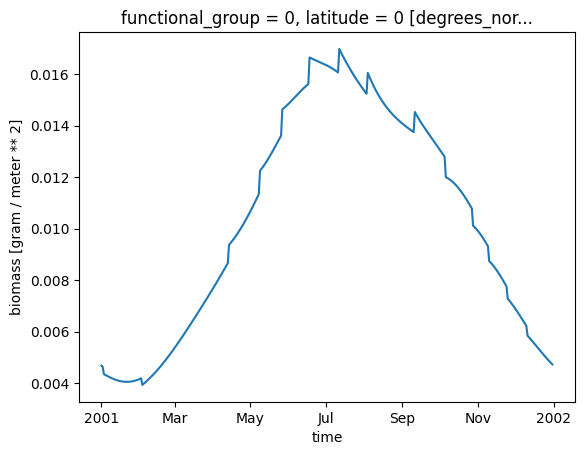

In [156]:
acidity_model2.state.biomass.pint.quantify().pint.to("g/m2").plot()

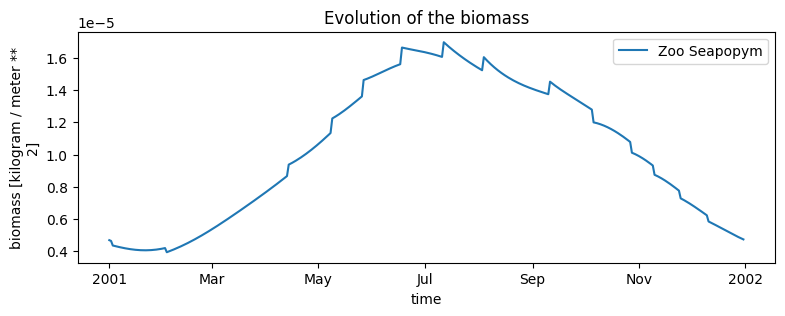

In [157]:
plt.figure(figsize=(9, 3))
acidity_model2.plot_biomass(label="Zoo Seapopym")
plt.legend()
plt.title("Evolution of the biomass")
plt.show()

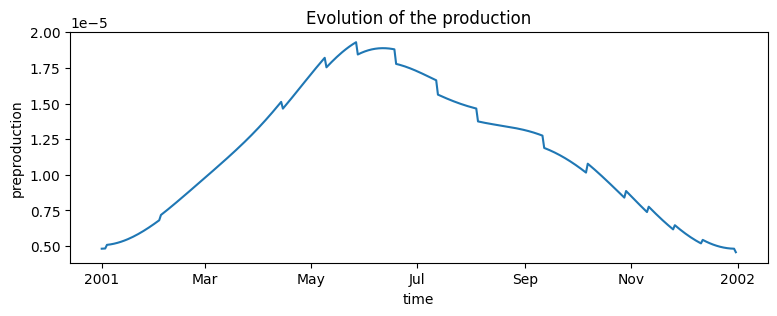

In [158]:
plt.figure(figsize=(9, 3))
acidity_model2.state.preproduction[0].cf.mean(("X", "Y")).cf.sum("cohort").cf.plot.line(x="T")
plt.title("Evolution of the production")
plt.show()